---
### 01. 머신러닝 실습 1
- [회귀] 광고비에 따른 매출 예측
---

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df = pd.read_csv('data/advertising.csv')
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [41]:
#결측치 확인
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [42]:
# 변수타입
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [43]:
# 매출과 변수들의 상관관계
df.corr()['Sales']

,Sales
TV,0.782224
Radio,0.576223
Newspaper,0.228299
Sales,1.000000


               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


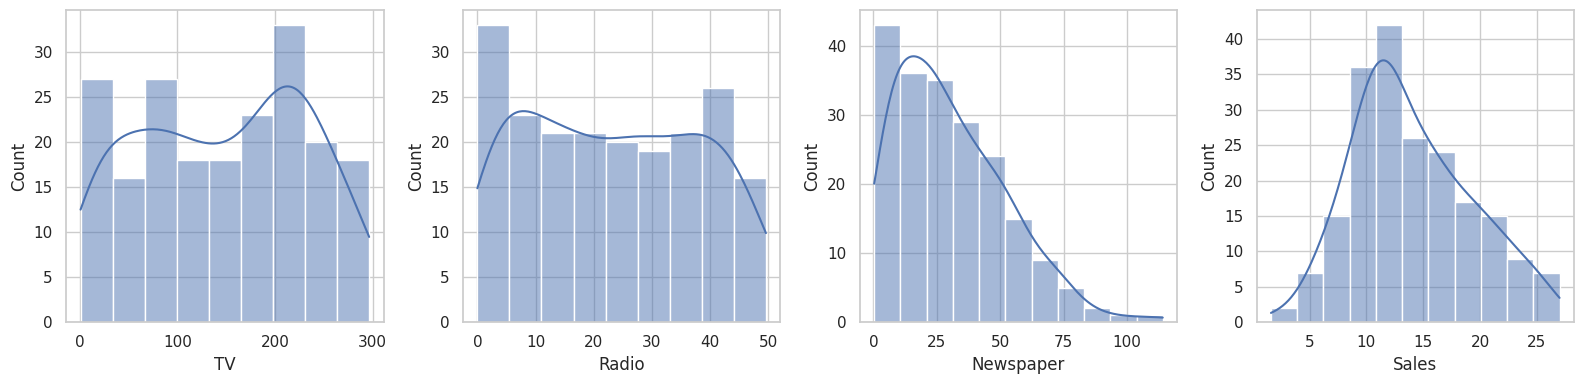

In [44]:
# 분포 확인
print(df.describe())

fig, axes = plt.subplots(1,4,figsize=(16,4))
sns.histplot(df['TV'], kde=True, ax=axes[0])
sns.histplot(df['Radio'], kde=True, ax=axes[1])
sns.histplot(df['Newspaper'], kde=True, ax=axes[2])
sns.histplot(df['Sales'], kde=True, ax=axes[3])

plt.tight_layout()
plt.show()

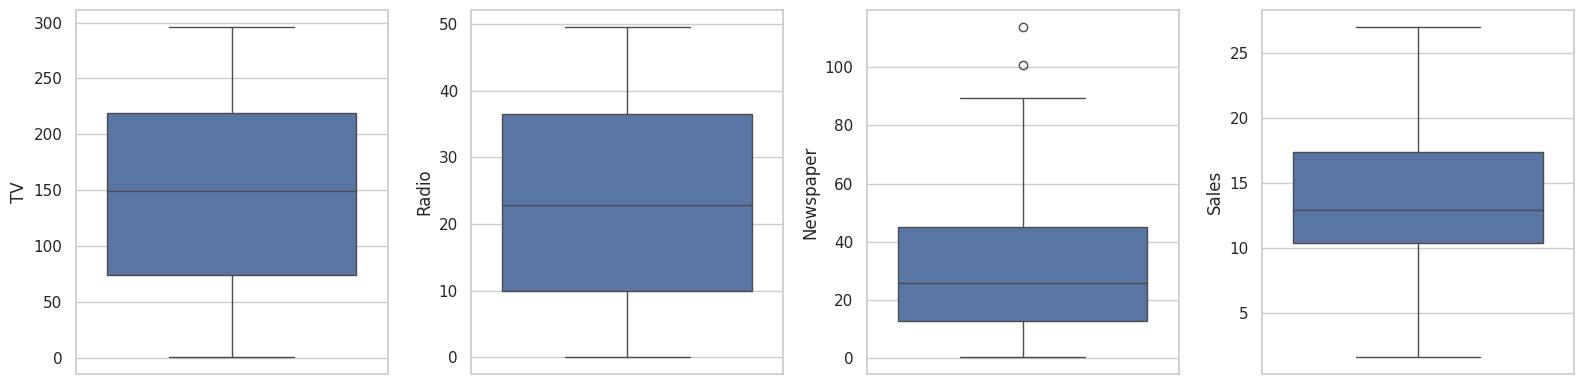

In [45]:
# 이상치 확인
fig, axes = plt.subplots(1,4,figsize=(16,4))
sns.boxplot(df['TV'], ax=axes[0])
sns.boxplot(df['Radio'], ax=axes[1])
sns.boxplot(df['Newspaper'], ax=axes[2])
sns.boxplot(df['Sales'], ax=axes[3])

plt.tight_layout()
plt.show()

#### 데이터 전처리

In [46]:
# 타겟변수 분리
y = df['Sales']
X = df.drop('Sales', axis=1)

# 검증데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

#### 모델링

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_valid)
rmse = root_mean_squared_error(y_valid, pred)
mse = mean_squared_error(y_valid, pred)
mae = mean_absolute_error(y_valid, pred)
mape = mean_absolute_percentage_error(y_valid, pred)
r2 = r2_score(y_valid, pred)

#### 평가지표 확인

In [48]:
result_df = pd.DataFrame({
    'RMSE': [rmse],
    'MSE': [mse],
    'MAE': [mae],
    'MAPE': [mape],
    'R2': [r2]
})

result_df

,RMSE,MSE,MAE,MAPE,R2
0,1.7816,3.174097,1.460757,0.151988,0.899438


- MAE 1.460757 : 모델이 예측한 매출은 실제와 대략 1.5천 달러 차이가 발생할 것으로 예상됨
- MAEP 0.151988 : 이는 즉 약 오차수준이 약 15.2%임을 의미함
- R2 0.899438 : 모델의 설명력은 약 89.9% 수준임